In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Change to project root
if Path.cwd().name == "pvlib":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

REPO = Path.home() / "pv_forecast_30d"

TRAIN_BASE = REPO / "data/processed/pretraining/germany/global/tft_inputs/regional_train_tft_base.parquet"
VAL_BASE   = REPO / "data/processed/pretraining/germany/global/tft_inputs/regional_val_tft_base.parquet"

TRAIN_PVLIB = REPO / "data/processed/pretraining/germany/global/pvlib_tft/regional_train_pvlib_tft.parquet"
VAL_PVLIB   = REPO / "data/processed/pretraining/germany/global/pvlib_tft/regional_val_pvlib_tft.parquet"

KEYS = ["plant_id", "timestamp_utc"]

def load_merge(base_path, pvlib_path):
    base = pd.read_parquet(base_path)
    pv   = pd.read_parquet(pvlib_path)
    base["timestamp_utc"] = pd.to_datetime(base["timestamp_utc"], utc=True)
    pv["timestamp_utc"]   = pd.to_datetime(pv["timestamp_utc"], utc=True)

    df = base.merge(pv, on=KEYS, how="inner", validate="one_to_one")

    # pick pvlib power-like column
    candidates = [c for c in df.columns if c.startswith("pvlib_") and c.endswith("_kw")]
    if not candidates:
        candidates = [c for c in df.columns if "pvlib" in c.lower() and "kw" in c.lower()]
    if not candidates:
        raise ValueError("Could not find pvlib power column. Hardcode it here.")
    pvcol = candidates[0]

    return df, pvcol

train, PVCOL = load_merge(TRAIN_BASE, TRAIN_PVLIB)
val, _       = load_merge(VAL_BASE,   VAL_PVLIB)

plants = sorted(train["plant_id"].unique().tolist())
print("PVLIB power column:", PVCOL)
print("plants:", plants)
print("train rows:", len(train), "val rows:", len(val))


PVLIB power column: pvlib_dc_kw
plants: ['plant_01', 'plant_02', 'plant_03', 'plant_05', 'plant_06']
train rows: 142190 val rows: 36952


# Correct diurnal timing (median day profile, PVLib vs measured)

This checks if PVLib peaks at the right time and shape daily.

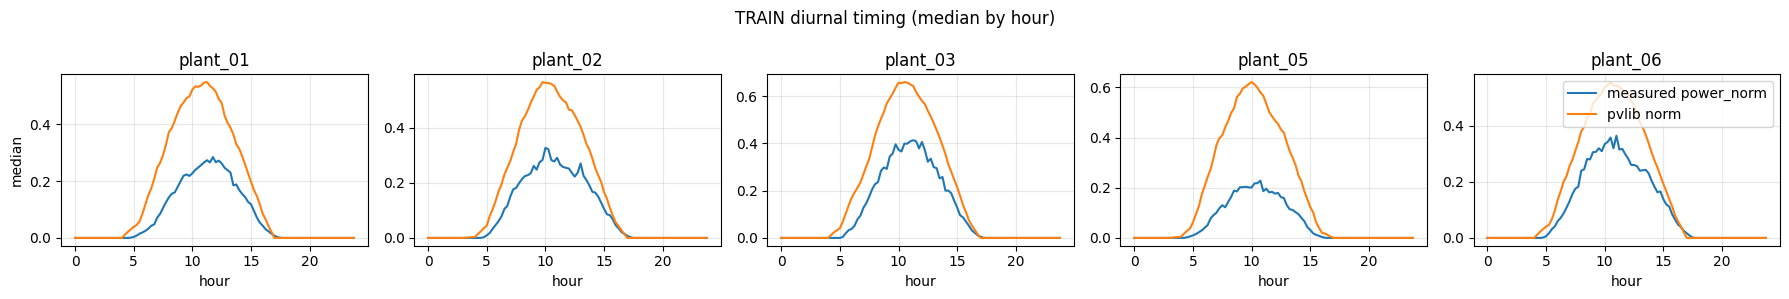

In [3]:
def plot_diurnal(df, title):
    df = df.copy()
    df["hour"] = df["timestamp_utc"].dt.hour + df["timestamp_utc"].dt.minute / 60.0

    fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
    for ax, pid in zip(axes, plants):
        d = df[df["plant_id"] == pid]
        if len(d) == 0:
            ax.set_title(pid + " (no data)")
            continue

        # normalize pvlib per plant to compare timing/shape, not scale
        pv = d[PVCOL].astype(float)
        pv_norm = (pv - pv.min()) / (pv.max() - pv.min() + 1e-9)

        g = d.assign(pvlib_norm=pv_norm).groupby("hour")[["power_norm", "pvlib_norm"]].median()

        ax.plot(g.index, g["power_norm"].to_numpy(), label="measured power_norm")
        ax.plot(g.index, g["pvlib_norm"].to_numpy(), label="pvlib norm")
        ax.set_title(pid)
        ax.set_xlabel("hour")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("median")
    axes[-1].legend(loc="best")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_diurnal(train, "TRAIN diurnal timing (median by hour)")


# No crazy negatives or insane spikes (distribution + spike rate)

This is blunt: it shows min/max and spike counts per plant, and plots PVLib series for a small window so you can visually spot exploding values.

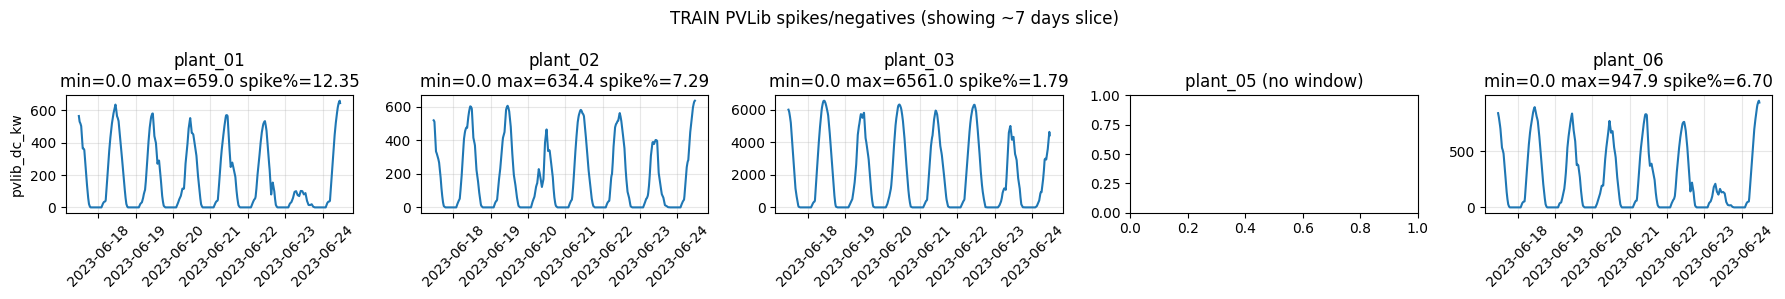

In [4]:
def plot_spikes(df, title, days=7):
    df = df.copy()
    df = df.sort_values(["plant_id", "timestamp_utc"])

    # pick a small window near the middle of the split
    t0 = df["timestamp_utc"].min() + (df["timestamp_utc"].max() - df["timestamp_utc"].min())/2
    t1 = t0 + pd.Timedelta(days=days)

    fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=False)
    for ax, pid in zip(axes, plants):
        d = df[(df["plant_id"] == pid) & (df["timestamp_utc"] >= t0) & (df["timestamp_utc"] <= t1)].copy()
        if len(d) == 0:
            ax.set_title(pid + " (no window)")
            continue

        pv = d[PVCOL].astype(float)

        # crude spike detection: jump > 5x median absolute diff
        dif = pv.diff().abs()
        thr = 5 * np.nanmedian(dif.values)
        spike_rate = float((dif > thr).mean()) if np.isfinite(thr) and thr > 0 else 0.0

        ax.plot(d["timestamp_utc"], pv, label="pvlib_kw")
        ax.set_title(f"{pid}\nmin={pv.min():.1f} max={pv.max():.1f} spike%={100*spike_rate:.2f}")
        ax.tick_params(axis="x", rotation=45)
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel(PVCOL)
    fig.suptitle(title + f" (showing ~{days} days slice)")
    plt.tight_layout()
    plt.show()

plot_spikes(train, "TRAIN PVLib spikes/negatives")


# Plant-specific scaling consistency (PVLib peak vs measured peak per plant)

This checks whether PVLib is wildly mis-scaled for any plant (common if capacity metadata is wrong).

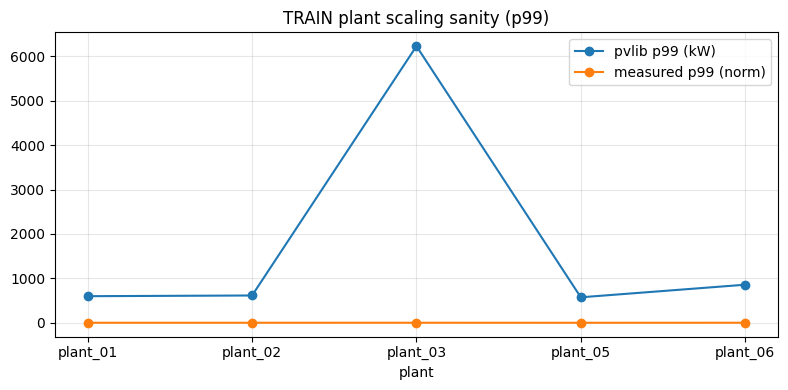

In [5]:
def plot_scaling(df, title):
    rows = []
    for pid in plants:
        d = df[df["plant_id"] == pid]
        if len(d) == 0:
            continue

        pv = d[PVCOL].astype(float)
        meas = d["power_norm"].astype(float)

        # compare robust "peak" (99th percentile)
        pv_p99 = float(np.nanpercentile(pv.values, 99))
        meas_p99 = float(np.nanpercentile(meas.values, 99))

        rows.append({"plant_id": pid, "pvlib_p99_kw": pv_p99, "measured_p99_norm": meas_p99})

    s = pd.DataFrame(rows).sort_values("plant_id")
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(s["plant_id"], s["pvlib_p99_kw"], marker="o", label="pvlib p99 (kW)")
    ax.plot(s["plant_id"], s["measured_p99_norm"], marker="o", label="measured p99 (norm)")
    ax.set_title(title)
    ax.set_xlabel("plant")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_scaling(train, "TRAIN plant scaling sanity (p99)")


### About plant 3 99th percentile peak → 7358.94kW
roughly plant 3 is 10 times bigger than plants 1,2,5 and almost 20 times of plant 6

In [1]:
import pandas as pd
from pathlib import Path

BASE = Path.home()/ "pv_forecast_30d/data/processed/pretraining/germany/global/tft_inputs/regional_val_tft_base.parquet"
df = pd.read_parquet(BASE)
g = df[df["plant_id"]=="plant_03"]["power_norm"].astype(float)
print("plant_03 power_norm min/max:", g.min(), g.max())
print(g.describe())


plant_03 power_norm min/max: 0.0 0.4351585014409222
count    2781.000000
mean        0.010936
std         0.036066
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         0.435159
Name: power_norm, dtype: float64


In [2]:
PV = Path.home()/ "pv_forecast_30d/data/processed/pretraining/germany/global/pvlib_tft/regional_val_pvlib_tft.parquet"
pv = pd.read_parquet(PV)
m = df[df["plant_id"]=="plant_03"][["plant_id","timestamp_utc","power_norm"]].merge(
    pv[pv["plant_id"]=="plant_03"][["plant_id","timestamp_utc","pvlib_dc_kw"]],
    on=["plant_id","timestamp_utc"],
    how="inner"
)
print(m[["power_norm","pvlib_dc_kw"]].describe())


        power_norm  pvlib_dc_kw
count  2781.000000  2781.000000
mean      0.010936   347.263123
std       0.036066   749.971497
min       0.000000     0.000000
25%       0.000000     0.000000
50%       0.000000     0.000000
75%       0.000000   225.922485
max       0.435159  4225.898926


In [ ]:
import json
META = Path.home()/ "pv_forecast_30d/data/metadata/germany/plant_03.json"
meta = json.loads(META.read_text())
cap_kw = meta.get("installed_capacity_kw") 
print("capacity_kw used:", cap_kw)

m["measured_kw"] = m["power_norm"].astype(float) * float(cap_kw)
print(m[["measured_kw","pvlib_dc_kw"]].describe())


capacity_kw used: 7358.9
       measured_kw  pvlib_dc_kw
count  2781.000000  2781.000000
mean     80.475279   347.263123
std     265.404175   749.971497
min       0.000000     0.000000
25%       0.000000     0.000000
50%       0.000000     0.000000
75%       0.000000   225.922485
max    3202.287896  4225.898926
